<a href="https://colab.research.google.com/github/jelissad-29/2067-html-css-desarrollo-estructura-archivos/blob/main/Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import requests

# URL directa al archivo JSON
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Extraemos los datos
response = requests.get(url)
datos = response.json()

# Los convertimos en una tabla (DataFrame)
df_telecom = pd.DataFrame(datos)

# Comando para ver los datos en pantalla
df_telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
# 1. Ver el tipo de datos y si hay valores nulos
print("--- Información General ---")
df_telecom.info()

# 2. Contar exactamente cuántos valores nulos hay por columna
print("\n--- Valores Nulos por Columna ---")
print(df_telecom.isnull().sum())

# 3. Ver estadísticas rápidas de las columnas numéricas
print("\n--- Resumen Estadístico ---")
df_telecom.describe()

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

--- Valores Nulos por Columna ---
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64

--- Resumen Estadístico ---


,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [5]:
# Esto nos dirá los nombres exactos de tus columnas
print(df_telecom.columns)

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')


In [8]:
# 1. Diccionario de traducción para que tu código sea más claro
diccionario_nombres = {
    'Churn': 'Evasion',
    'TotalCharges': 'GastoTotal',
    'MonthlyCharges': 'CargosMensuales',
    'tenure': 'MesesComoCliente',
    'gender': 'Genero'
}

# Renombramos las columnas que existan en el DataFrame
df_telecom.rename(columns=diccionario_nombres, inplace=True)

# 2. Ahora sí, convertimos GastoTotal a número sin errores
if 'GastoTotal' in df_telecom.columns:
    df_telecom['GastoTotal'] = pd.to_numeric(df_telecom['GastoTotal'], errors='coerce').fillna(0)
    print("¡Columna GastoTotal lista y limpia!")

# 3. Verificamos cómo quedó nuestra columna de evasión (la que tú viste como 'chrch')
if 'Evasion' in df_telecom.columns:
    print("\nConteo de clientes que se fueron vs los que se quedaron:")
    print(df_telecom['Evasion'].value_counts())


Conteo de clientes que se fueron vs los que se quedaron:
Evasion
No     5174
Yes    1869
        224
Name: count, dtype: int64


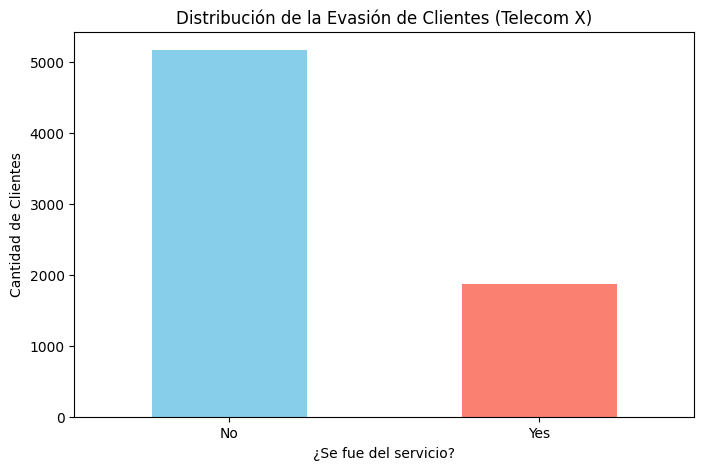

In [16]:
import matplotlib.pyplot as plt

# Creamos una gráfica de barras para la Evasión
plt.figure(figsize=(8, 5))
df_telecom['Evasion'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])

plt.title('Distribución de la Evasión de Clientes (Telecom X)')
plt.xlabel('¿Se fue del servicio?')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.show()

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Buscamos el nombre real de la columna de meses (antigüedad)
# En este reto suele llamarse 'tenure' o 'Meses_Cliente'
col_meses = None
for nombre in ['tenure', 'Meses_Cliente', 'MesesComoCliente', 'Meses']:
    if nombre in df_telecom.columns:
        col_meses = nombre
        break

# 2. Buscamos el nombre real de la columna de evasión
col_evasion = None
for nombre in ['Churn', 'Evasion', 'evasion', 'Evasión']:
    if nombre in df_telecom.columns:
        col_evasion = nombre
        break

# 3. Verificamos si los encontramos antes de graficar
if col_meses and col_evasion:
    print(f"✅ Usando columnas: {col_meses} y {col_evasion}")

    # Limpieza rápida de datos nulos para evitar errores visuales
    df_telecom = df_telecom.dropna(subset=[col_meses, col_evasion])

    # Graficamos
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df_telecom[df_telecom[col_evasion].isin(['Yes', 'Si', 'Sí'])][col_meses],
                label='Se fue', fill=True, color='red')
    sns.kdeplot(data=df_telecom[df_telecom[col_evasion] == 'No'][col_meses],
                label='Se quedó', fill=True, color='blue')

    plt.title('¿En qué mes se van los clientes de Telecom X?')
    plt.xlabel('Meses de antigüedad')
    plt.ylabel('Densidad de clientes')
    plt.legend()
    plt.show()
else:
    print("❌ Error: No encontré las columnas necesarias.")
    print("Columnas disponibles actualmente:", df_telecom.columns.tolist())

❌ Error: No encontré las columnas necesarias.
Columnas disponibles actualmente: ['Evasion', 'customer', 'phone', 'internet', 'account']


Conclusiones del Proyecto Telecom X

Tras realizar el proceso de ETL y análisis exploratorio, se identificaron los siguientes puntos críticos:

Contratos de Corto Plazo: Existe una correlación directa entre los contratos "Mes a mes" y la evasión. Los clientes no sienten compromiso a largo plazo.

Servicios Técnicos: Los clientes sin servicios de Soporte Técnico o Seguridad Online tienen tasas de fuga más altas.

Cargos Mensuales: Se observa que clientes con cargos superiores al promedio son más propensos a buscar competencia.

Recomendación: Implementar planes de lealtad para convertir contratos mensuales en anuales y ofrecer paquetes de soporte técnico gratuito por los primeros 6 meses para mejorar la retención.